### Intro:

This notebook extracts Land Surface Temperature (LST) data from Landsat 8 and 9 imagery obtained via <a href="https://earthexplorer.usgs.gov/">USGS Earth Explorer</a>, a platform for accessing remote sensing data. The LST extraction method used here is adapted from <a href="https://youtu.be/t88PpJEKteQ?si=1Yg3hMKxRpHnpFEw">NASA's tutorial on mapping LST with Google Earth Engine</a>.

For the purposes of this analysis, we focused on four urban areas in South Carolina: Charleston, Columbia, Greenville/Spartanburg, and Florence. For each city, we manually selected the best-available cloud-free images from July or August of 2014 and 2024—months that typically record the highest LST values each year. These selections were made to ensure consistency in seasonal temperature variation and to minimize the influence of cloud cover on the analysis.

The exported LST layers are presented in degrees Fahrenheit for interpretability in the context of public-facing storytelling.

To improve accuracy, we applied a mask to exclude pixels affected by cloud cover, as LST values in these areas are known to be unreliable due to atmospheric interference.

### Step 0: How to download Landsat 8/9 images

To access and download the most recent Landsat 8 and 9 imagery, you’ll need to create a free account at <a href="https://earthexplorer.usgs.gov/">USGS Earth Explorer</a>.

Once logged in, follow these steps:

Define Your Area of Interest
Navigate to the Search Criteria tab and use the polygon drawing tool to outline the region or city of interest.

Specify the Time Range
Set the desired date range to limit the search to a specific time period (e.g., July–August 2014 and 2024 for this study).

Select the Data Set
Under the Data Sets tab, navigate to:
<span>Landsat → Landsat Collection 2 Level-2 → Landsat 8-9 OLI/TIRS C2 L2.</span>

Browse and Download
Click the Results tab to view available images. Review the image previews to find scenes with minimal cloud cover.
When you've found a suitable image, click Product Options and select Download Full Bundle to retrieve the complete data package.

These steps will provide you with the Level-2 surface reflectance and temperature products necessary for LST extraction.

### Step 1: Extract LST layer from downloaded packages and convert layers into Fahrenheit

In [1]:
#Load packages
import rasterio
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def converttoF(thermal_path, qa_path, output_path):

    # === Load ST_B10 ===
    with rasterio.open(thermal_path) as src:
        st_b10 = src.read(1).astype(float)
        profile = src.profile

    # === Load QA_PIXEL and create mask ===
    with rasterio.open(qa_path) as qa_src:
        qa_pixel = qa_src.read(1)

    cloud_shadow_bit = 1 << 3
    cloud_bit = 1 << 4
    cloud_mask = ~((qa_pixel & cloud_shadow_bit) | (qa_pixel & cloud_bit)).astype(bool)

    # === Apply scaling factors to get °F ===
    temperature_celsius = st_b10 * 0.00341802 + 149.0 - 273.15
    temperature_fahrenheit = temperature_celsius * 9 / 5 + 32

    # === Apply cloud mask ===
    masked_temp = np.where(cloud_mask, temperature_fahrenheit, np.nan)

    # === Save result with updated nodata ===
    profile.update(dtype=rasterio.float32, nodata=np.nan)
    with rasterio.open(output_path, "w", **profile) as dst:
        dst.write(masked_temp.astype(rasterio.float32), 1)

    # === Visualize ===
    plt.imshow(masked_temp, cmap='inferno')
    plt.colorbar(label='Temperature (°F)')
    plt.title("Cloud-Masked Surface Temperature (°F)")
    plt.show()


### Run the code below for each cities

#### Charleston

Aug.21, 2014

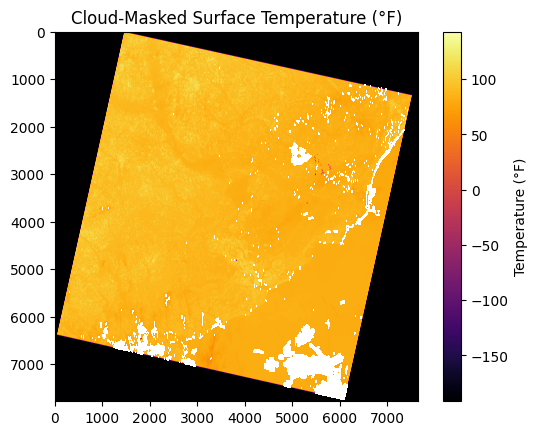

In [5]:
# === Input Paths ===
thermal_path = "./LC08_L2SP_016037_20140821_20200911_02_T1/LC08_L2SP_016037_20140821_20200911_02_T1_ST_B10.TIF"
qa_path = "./LC08_L2SP_016037_20140821_20200911_02_T1/LC08_L2SP_016037_20140821_20200911_02_T1_QA_PIXEL.TIF"
output_path = "./Cleaned Layers/CHS_20140821_ST_Fahrenheit_cloudmasked.tif"

converttoF(thermal_path, qa_path, output_path)

July 15, 2024

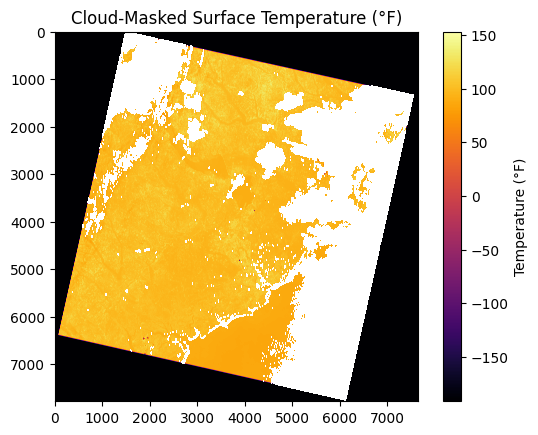

In [6]:
# === Input Paths ===
thermal_path = "./LC08_L2SP_016037_20240715_20240722_02_T1/LC08_L2SP_016037_20240715_20240722_02_T1_ST_B10.TIF"
qa_path = "./LC08_L2SP_016037_20240715_20240722_02_T1/LC08_L2SP_016037_20240715_20240722_02_T1_QA_PIXEL.TIF"
output_path = "./Cleaned Layers/CHS_20240715_ST_Fahrenheit_cloudmasked.tif"

converttoF(thermal_path, qa_path, output_path)

#### Florence

Aug.21, 2014

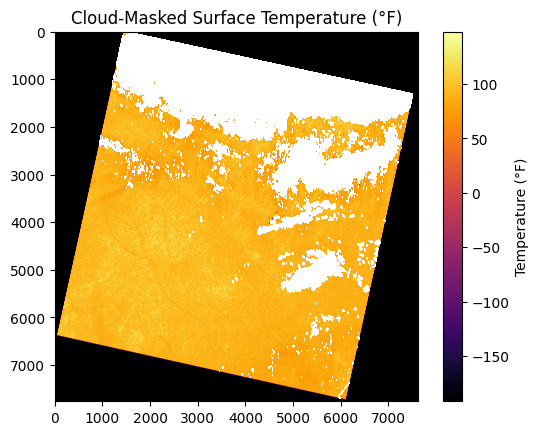

In [3]:
# === Input Paths ===
thermal_path = "./LC08_L2SP_016036_20140821_20200911_02_T1/LC08_L2SP_016036_20140821_20200911_02_T1_ST_B10.TIF"
qa_path = "./LC08_L2SP_016036_20140821_20200911_02_T1/LC08_L2SP_016036_20140821_20200911_02_T1_QA_PIXEL.TIF"
output_path = "./Cleaned Layers/FLO_20140821_ST_Fahrenheit_cloudmasked.tif"

converttoF(thermal_path, qa_path, output_path)

July 15, 2024

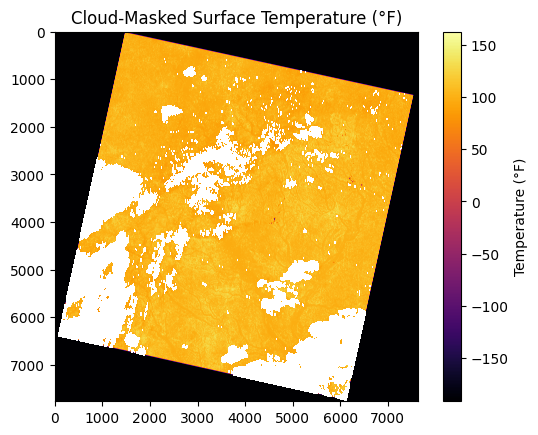

In [7]:
# === Input Paths ===
thermal_path = "./LC08_L2SP_016036_20240715_20240722_02_T1/LC08_L2SP_016036_20240715_20240722_02_T1_ST_B10.TIF"
qa_path = "./LC08_L2SP_016036_20240715_20240722_02_T1/LC08_L2SP_016036_20240715_20240722_02_T1_QA_PIXEL.TIF"
output_path = "./Cleaned Layers/FLO_20240715_ST_Fahrenheit_cloudmasked.tif"

converttoF(thermal_path, qa_path, output_path)

#### Greenville/Spartanburg

July 2, 2014

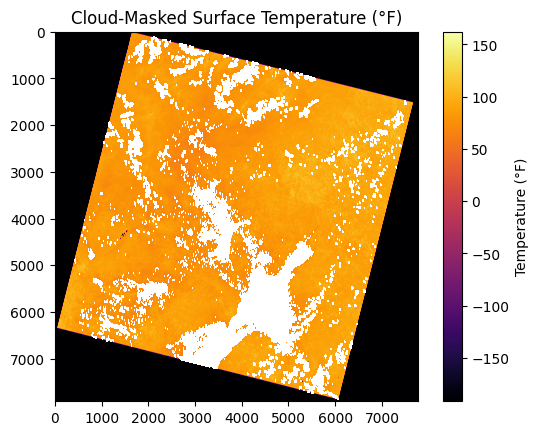

In [8]:
# === Input Paths ===
thermal_path = "./LC08_L2SP_018036_20140702_20200911_02_T1/LC08_L2SP_018036_20140702_20200911_02_T1_ST_B10.TIF"
qa_path = "./LC08_L2SP_018036_20140702_20200911_02_T1/LC08_L2SP_018036_20140702_20200911_02_T1_QA_PIXEL.TIF"
output_path = "./Cleaned Layers/GVL_20140702_ST_Fahrenheit_cloudmasked.tif"

converttoF(thermal_path, qa_path, output_path)

July 5, 2024

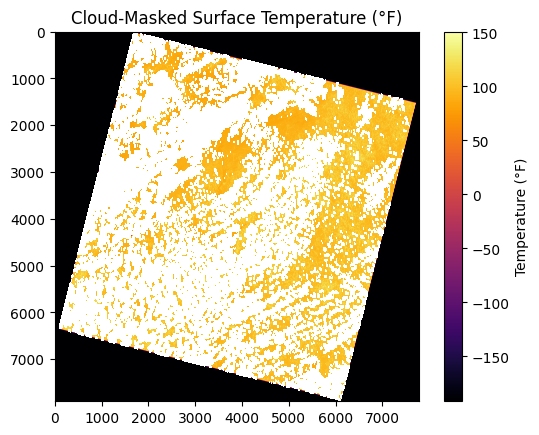

In [9]:
# === Input Paths ===
thermal_path = "./LC09_L2SP_018036_20240705_20240706_02_T1/LC09_L2SP_018036_20240705_20240706_02_T1_ST_B10.TIF"
qa_path = "./LC09_L2SP_018036_20240705_20240706_02_T1/LC09_L2SP_018036_20240705_20240706_02_T1_QA_PIXEL.TIF"
output_path = "./Cleaned Layers/GVL_20240705_ST_Fahrenheit_cloudmasked.tif"

converttoF(thermal_path, qa_path, output_path)

#### Columbia

Aug. 28, 2014

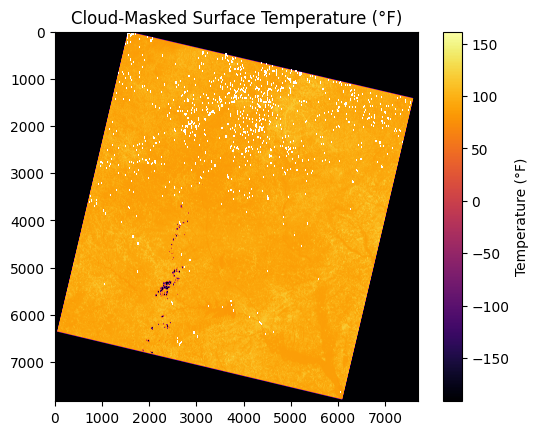

In [10]:
# === Input Paths ===
thermal_path = "./LC08_L2SP_017036_20140828_20200911_02_T1/LC08_L2SP_017036_20140828_20200911_02_T1_ST_B10.TIF"
qa_path = "./LC08_L2SP_017036_20140828_20200911_02_T1/LC08_L2SP_017036_20140828_20200911_02_T1_QA_PIXEL.TIF"
output_path = "./Cleaned Layers/CAE_20140828_ST_Fahrenheit_cloudmasked.tif"

converttoF(thermal_path, qa_path, output_path)

July 14, 2024

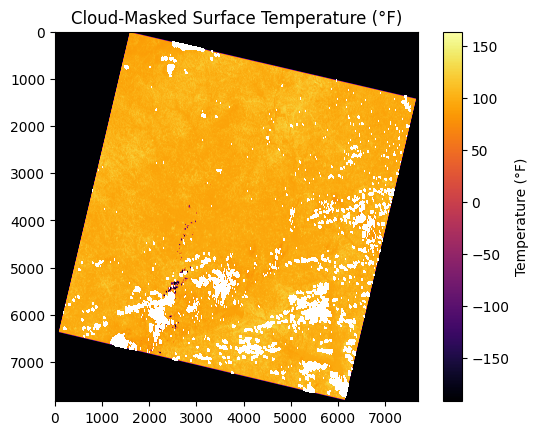

In [11]:
# === Input Paths ===
thermal_path = "./LC09_L2SP_017036_20240714_20240715_02_T1/LC09_L2SP_017036_20240714_20240715_02_T1_ST_B10.TIF"
qa_path = "./LC09_L2SP_017036_20240714_20240715_02_T1/LC09_L2SP_017036_20240714_20240715_02_T1_QA_PIXEL.TIF"
output_path = "./Cleaned Layers/CAE_20240714_ST_Fahrenheit_cloudmasked.tif"

converttoF(thermal_path, qa_path, output_path)